In [1]:
!pip install -q transformers datasets torch torchvision scikit-learn tqdm wandb
print("All packages installed.")

All packages installed.


In [2]:
from google.colab import drive
drive.mount('/content/drive')
!cp "/content/drive/MyDrive/Dataset/PlantDoc-Dataset-master.zip" .
!unzip -q PlantDoc-Dataset-master.zip

Mounted at /content/drive


In [3]:
import random
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms

# ── GLOBAL SEED ──────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # trade throughput for determinism
os.environ['PYTHONHASHSEED'] = str(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Seeds set to {SEED}.")
print(f"Device: {device}")

Seeds set to 42.
Device: cuda


In [5]:
from datasets import load_dataset

# ── LOAD DATASET FROM UNZIPPED GOOGLE DRIVE DATASET ──────────────────────────
IMAGEFOLDER_PATH = "/content/PlantDoc-Dataset-master"

print(f"Loading dataset from: {IMAGEFOLDER_PATH}")

raw_dataset = load_dataset("imagefolder", data_dir=IMAGEFOLDER_PATH)

train_full   = raw_dataset["train"]
test_set_raw = raw_dataset.get("test", None)

# ── SPLIT TRAIN → TRAIN/VALIDATION (80/20) ──────────────────────────────────
split = train_full.train_test_split(test_size=0.2, seed=42)

train_raw = split["train"]
val_raw   = split["test"]

# ── PRINT DATASET SIZES ──────────────────────────────────────────────────────
print(f"\nDataset sizes (before transforms):")
print(f"  Train : {len(train_raw)}")
print(f"  Val   : {len(val_raw)}")

if test_set_raw is not None:
    print(f"  Test  : {len(test_set_raw)}")
else:
    print("  Test  : using val split (no separate test folder found)")
    test_set_raw = val_raw

Loading dataset from: /content/PlantDoc-Dataset-master


Resolving data files:   0%|          | 0/2342 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/236 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]


Dataset sizes (before transforms):
  Train : 1873
  Val   : 469
  Test  : 236


In [7]:
# ── BUILD LABEL MAP ──────────────────────────────────────────────────────────
# Creates stable label2id and id2label mappings from all dataset splits

def _get_label_name(item, features):
    """Extract label name from dataset sample."""

    # Object detection style datasets
    if 'objects' in item and 'category' in item.get('objects', {}):
        cats = item['objects']['category']

        if cats:
            return str(cats[0])

    # Classification datasets with string labels
    if 'label' in item and isinstance(item['label'], str):
        return item['label']

    # Classification datasets with integer labels
    if 'label' in item and isinstance(item['label'], int):

        if hasattr(features.get('label', None), 'names') and features['label'].names:
            idx = item['label']

            if 0 <= idx < len(features['label'].names):
                return features['label'].names[idx]

        return str(item['label'])

    return None


features = train_raw.features

all_labels = set()
missing = 0

# Collect labels from all dataset splits
for split_ds in [train_raw, val_raw, test_set_raw]:

    for sample in split_ds:
        name = _get_label_name(sample, features)

        if name is None:
            missing += 1
        else:
            all_labels.add(name)

# Warn if labels are missing
if missing > 0:
    print(f"Warning: {missing} samples had no label.")

# Create label mappings
label_names = sorted(all_labels)

label2id = {n: i for i, n in enumerate(label_names)}
id2label = {i: n for i, n in enumerate(label_names)}

num_classes = len(label_names)

# Print dataset information
print(f"Found {num_classes} classes.")
print(f"First 5: {label_names[:5]}")
print(f"Last  5: {label_names[-5:]}")

Found 28 classes.
First 5: ['Apple Scab Leaf', 'Apple leaf', 'Apple rust leaf', 'Bell_pepper leaf', 'Bell_pepper leaf spot']
Last  5: ['Tomato leaf yellow virus', 'Tomato mold leaf', 'Tomato two spotted spider mites leaf', 'grape leaf', 'grape leaf black rot']


In [8]:
# ── TRAIN TRANSFORMS WITH DATA AUGMENTATION ──────────────────────────────────
# Applies random augmentations to improve model generalization

train_transforms = transforms.Compose([
    transforms.Resize(256),

    # Random crop for better robustness to scale and positioning
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),

    # Random horizontal flipping
    transforms.RandomHorizontalFlip(p=0.5),

    # Small random rotations
    transforms.RandomRotation(15),

    # Random brightness, contrast, saturation, and hue changes
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.05
    ),

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize using ImageNet mean and standard deviation
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# ── VALIDATION / TEST TRANSFORMS ─────────────────────────────────────────────
# Uses deterministic preprocessing without augmentation

val_transforms = transforms.Compose([
    transforms.Resize(256),

    # Center crop to model input size
    transforms.CenterCrop(224),

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize using ImageNet statistics
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

print("Train transforms: Resize→RandomResizedCrop→HFlip→Rotation→ColorJitter→Normalize")
print("Val transforms:   Resize→CenterCrop→Normalize")

Train transforms: Resize→RandomResizedCrop→HFlip→Rotation→ColorJitter→Normalize
Val transforms:   Resize→CenterCrop→Normalize


In [9]:
# ── PREPROCESSING FUNCTIONS ──────────────────────────────────────────────────
# Applies image transformations and creates pixel_values for the model

def preprocess_train(examples):

    # Apply training augmentations to training images
    examples['pixel_values'] = [
        train_transforms(img.convert('RGB'))
        for img in examples['image']
    ]

    return examples


def preprocess_val(examples):

    # Apply validation/test preprocessing without augmentation
    examples['pixel_values'] = [
        val_transforms(img.convert('RGB'))
        for img in examples['image']
    ]

    return examples


# ── APPLY TRANSFORMS TO DATASET SPLITS ───────────────────────────────────────
# Training set uses augmentation
# Validation and test sets use deterministic preprocessing

train_raw.set_transform(preprocess_train)
val_raw.set_transform(preprocess_val)
test_set_raw.set_transform(preprocess_val)

print("Transforms applied:")
print(f"  train_raw  → augmented train_transforms")
print(f"  val_raw    → clean val_transforms")
print(f"  test_set   → clean val_transforms")

Transforms applied:
  train_raw  → augmented train_transforms
  val_raw    → clean val_transforms
  test_set   → clean val_transforms


In [15]:
# ── COLLATE FUNCTION ─────────────────────────────────────────────────────────
# Combines individual dataset samples into training batches

def collate_fn(batch):

    pixel_values = []
    labels_out   = []

    for item in batch:

        # Collect transformed image tensors
        pixel_values.append(item['pixel_values'])

        # Extract label name
        name = _get_label_name(item, features)

        # Check for missing labels
        if name is None:
            raise ValueError(
                f"Sample has no valid label. Keys: {list(item.keys())}"
            )

        # Check for unknown labels
        if name not in label2id:
            raise ValueError(
                f"Unknown label '{name}' not in label2id map."
            )

        # Convert label name to numeric ID
        labels_out.append(label2id[name])

    # Stack image tensors into a batch
    pixel_values = torch.stack(pixel_values)

    # Convert labels to tensor
    labels_out = torch.tensor(labels_out, dtype=torch.long)

    return {
        'pixel_values': pixel_values,
        'labels': labels_out
    }


# ── DATALOADERS ───────────────────────────────────────────────────────────────
# Creates PyTorch DataLoaders for training, validation, and testing

BATCH_SIZE = 32

# num_workers can be reduced to 0 if worker-related errors occur in Colab

train_loader = DataLoader(
    train_raw,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_raw,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_set_raw,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

# Display DataLoader information
print(f"Train loader: {len(train_loader)} batches × {BATCH_SIZE} = ~{len(train_loader)*BATCH_SIZE} samples")
print(f"Val   loader: {len(val_loader)} batches")
print(f"Test  loader: {len(test_loader)} batches")

Train loader: 59 batches × 32 = ~1888 samples
Val   loader: 15 batches
Test  loader: 8 batches


In [16]:
from transformers import MobileNetV2ForImageClassification

# ── LOAD PRETRAINED MODEL ─────────────────────────────────────────────────────
# Loads a pretrained MobileNetV2 model for plant disease classification

model_id = "linkanjarad/mobilenet_v2_1.0_224-plant-disease-identification"

print(f"Loading: {model_id}")

model = MobileNetV2ForImageClassification.from_pretrained(
    model_id,

    # Allows replacement of the final classification layer
    ignore_mismatched_sizes=True,
)

# ── SET BACKBONE DROPOUT ─────────────────────────────────────────────────────
# Reduces dropout probability in the pretrained backbone

model.dropout.p = 0.1

print(f"Backbone dropout set to: {model.dropout.p}")

# ── GET BACKBONE FEATURE SIZE ────────────────────────────────────────────────
# Retrieves the output feature dimension from the classifier input

if isinstance(model.classifier, nn.Sequential):
    in_features = model.classifier[-1].in_features
else:
    in_features = model.classifier.in_features

print(f"Backbone output features: {in_features}")

# ── BUILD CUSTOM CLASSIFIER HEAD ─────────────────────────────────────────────
# Replaces the original classifier with a deeper fully connected head

model.classifier = nn.Sequential(

    nn.Linear(in_features, 640),
    nn.ReLU(),

    nn.Linear(640, 320),
    nn.Dropout(p=0.1),
    nn.ReLU(),

    nn.Linear(320, num_classes),
)

print(f"Classifier head: {in_features}→640→320→{num_classes}")

# ── INITIALIZE CLASSIFIER WEIGHTS ────────────────────────────────────────────
# Applies Xavier Uniform initialization to linear layers

for layer in model.classifier:

    if isinstance(layer, nn.Linear):
        nn.init.xavier_uniform_(layer.weight)
        nn.init.zeros_(layer.bias)

print("Xavier Uniform init applied to all classifier Linear layers.")

# ── MOVE MODEL TO DEVICE ─────────────────────────────────────────────────────
# Sends model to GPU if available

model.to(device)

# ── DISPLAY MODEL INFORMATION ────────────────────────────────────────────────
total = sum(p.numel() for p in model.parameters())

trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"\nTotal params: {total:,}  |  Trainable: {trainable:,}")

print("\nClassifier head:")
print(model.classifier)

Loading: linkanjarad/mobilenet_v2_1.0_224-plant-disease-identification


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

Backbone dropout set to: 0.1
Backbone output features: 1280
Classifier head: 1280→640→320→28
Xavier Uniform init applied to all classifier Linear layers.

Total params: 3,257,820  |  Trainable: 3,257,820

Classifier head:
Sequential(
  (0): Linear(in_features=1280, out_features=640, bias=True)
  (1): ReLU()
  (2): Linear(in_features=640, out_features=320, bias=True)
  (3): Dropout(p=0.1, inplace=False)
  (4): ReLU()
  (5): Linear(in_features=320, out_features=28, bias=True)
)


In [17]:
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import copy

# ── HELPER FUNCTION FOR FROZEN BATCHNORM LAYERS ─────────────────────────────
# Keeps frozen BatchNorm layers in evaluation mode during training

def set_frozen_bn_eval(module):

    for m in module.modules():

        if isinstance(m, nn.BatchNorm2d):

            if not any(p.requires_grad for p in m.parameters()):
                m.eval()


# ── TRAINING FUNCTION FOR ONE EPOCH ──────────────────────────────────────────
# Performs one full training pass over the dataset

def train_one_epoch(
    model,
    loader,
    optimizer,
    scheduler,
    criterion,
    device,
    epoch,
    total_epochs
):

    model.train()

    # Keep frozen BatchNorm layers in eval mode
    set_frozen_bn_eval(model)

    total_loss = 0.0

    all_preds  = []
    all_labels = []

    bar = tqdm(
        loader,
        desc=f"Epoch {epoch+1}/{total_epochs} [Train]",
        leave=True
    )

    for batch in bar:

        pv = batch['pixel_values'].to(device, non_blocking=True)

        labels = batch['labels'].to(device, non_blocking=True)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(pv).logits

        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad],
            max_norm=1.0
        )

        optimizer.step()

        scheduler.step()

        total_loss += loss.item()

        # Store predictions and labels
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)

        all_labels.extend(labels.cpu().numpy())

        bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(loader)

    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc


# ── VALIDATION FUNCTION ──────────────────────────────────────────────────────
# Evaluates model performance on validation or test data

def validate(
    model,
    loader,
    criterion,
    device,
    epoch,
    total_epochs,
    desc="Val"
):

    model.eval()

    total_loss = 0.0

    all_preds  = []
    all_labels = []

    with torch.no_grad():

        for batch in tqdm(
            loader,
            desc=f"Epoch {epoch+1}/{total_epochs} [{desc}]",
            leave=False
        ):

            pv = batch['pixel_values'].to(device, non_blocking=True)

            labels = batch['labels'].to(device, non_blocking=True)

            # Forward pass
            outputs = model(pv).logits

            loss = criterion(outputs, labels)

            total_loss += loss.item()

            # Store predictions and labels
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            all_preds.extend(preds)

            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)

    acc = accuracy_score(all_labels, all_preds)

    _, _, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average='weighted',
        zero_division=0
    )

    return avg_loss, acc, f1


print("Training utilities defined.")

print("  set_frozen_bn_eval()  — keeps frozen BN in eval mode")

print("  train_one_epoch()     — training loop with gradient clipping")

print("  validate()            — evaluation loop with loss, accuracy, and weighted F1")

Training utilities defined.
  set_frozen_bn_eval()  — keeps frozen BN in eval mode
  train_one_epoch()     — training loop with gradient clipping
  validate()            — evaluation loop with loss, accuracy, and weighted F1


In [18]:
from transformers import get_linear_schedule_with_warmup

# ── FREEZE BACKBONE PARAMETERS ───────────────────────────────────────────────
# Freezes pretrained MobileNetV2 backbone layers

for param in model.mobilenet_v2.parameters():
    param.requires_grad = False

# Keeps classifier head trainable
for param in model.classifier.parameters():
    param.requires_grad = True

# Collect trainable parameters
trainable_p1 = [
    p for p in model.parameters()
    if p.requires_grad
]

print(f"Phase 1 — Frozen backbone. Trainable tensors: {len(trainable_p1)}")

print(f"Trainable params: {sum(p.numel() for p in trainable_p1):,}")

# ── LOSS FUNCTION ────────────────────────────────────────────────────────────
# CrossEntropyLoss with label smoothing

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

# ── OPTIMIZER ────────────────────────────────────────────────────────────────
# AdamW optimizer for classifier head training

optimizer_p1 = optim.AdamW(
    trainable_p1,

    lr=1e-4,

    betas=(0.9, 0.999),

    weight_decay=1e-2,
)

# ── TRAINING CONFIGURATION ───────────────────────────────────────────────────
# Defines total steps and warmup schedule

EPOCHS_P1 = 10

steps_p1 = len(train_loader) * EPOCHS_P1

# Warmup for first 10% of training steps
warmup_p1 = int(0.1 * steps_p1)

# ── LEARNING RATE SCHEDULER ──────────────────────────────────────────────────
# Linear decay scheduler with warmup

scheduler_p1 = get_linear_schedule_with_warmup(
    optimizer_p1,

    num_warmup_steps=warmup_p1,

    num_training_steps=steps_p1,
)

print(
    f"\nPhase 1: {EPOCHS_P1} epochs, "
    f"LR=1e-4, linear schedule, warmup={warmup_p1} steps"
)

Phase 1 — Frozen backbone. Trainable tensors: 6
Trainable params: 1,033,948

Phase 1: 10 epochs, LR=1e-4, linear schedule, warmup=59 steps


In [22]:
!pip install -q wandb

import wandb

In [23]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: chinmoydeb2005 (chinmoydeb2005-vellore-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [24]:
wandb.init(
    project="plantdoc-mobilenetv2",
    name="phase1-phase2-training",

    config={
        "batch_size": BATCH_SIZE,
        "phase1_epochs": EPOCHS_P1,
        "phase2_epochs": EPOCHS_P2,
        "phase1_lr": 1e-4,
        "phase2_lr": 4e-5,
        "model": model_id,
        "image_size": 224,
        "optimizer": "AdamW",
    }
)

In [25]:
# ── PHASE 1 TRAINING ─────────────────────────────────────────────────────────
# Trains only the classifier head while keeping the backbone frozen

print("=" * 60)
print("PHASE 1: Frozen Backbone — Training Classifier Head Only")
print("=" * 60)

best_val_acc_p1 = 0.0

best_model_state = None

history_p1 = []

# ── TRAINING LOOP ────────────────────────────────────────────────────────────
for epoch in range(EPOCHS_P1):

    # Train for one epoch
    tr_loss, tr_acc = train_one_epoch(
        model,
        train_loader,
        optimizer_p1,
        scheduler_p1,
        criterion,
        device,
        epoch,
        EPOCHS_P1
    )

    # Validate model
    val_loss, val_acc, val_f1 = validate(
        model,
        val_loader,
        criterion,
        device,
        epoch,
        EPOCHS_P1
    )

    # Store training history
    history_p1.append({
        'epoch': epoch + 1,

        'tr_loss': tr_loss,
        'tr_acc': tr_acc,

        'val_loss': val_loss,
        'val_acc': val_acc,
        'val_f1': val_f1
    })

    # ── LOG METRICS TO WANDB ─────────────────────────────────────────────────
    # Tracks training and validation performance for each epoch

    wandb.log({
        "phase": 1,

        "epoch": epoch + 1,

        "train_loss": tr_loss,
        "train_acc": tr_acc,

        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,

        "learning_rate": optimizer_p1.param_groups[0]["lr"]
    })

    flag = ""

    # Save best model based on validation accuracy
    if val_acc > best_val_acc_p1:

        best_val_acc_p1 = val_acc

        best_model_state = copy.deepcopy(model.state_dict())

        flag = "  ← best"

    # Print epoch results
    print(
        f"Epoch {epoch+1:02d}/{EPOCHS_P1} | "
        f"Train Loss={tr_loss:.4f} Acc={tr_acc:.4f} | "
        f"Val Loss={val_loss:.4f} Acc={val_acc:.4f} "
        f"F1={val_f1:.4f}{flag}"
    )

# ── SAVE BEST PHASE 1 MODEL ─────────────────────────────────────────────────
print(
    f"\nPhase 1 complete. "
    f"Best val accuracy: {best_val_acc_p1:.4f} "
    f"({best_val_acc_p1*100:.1f}%)"
)

torch.save(best_model_state, "phase1_best.pth")

# Save model checkpoint to Weights & Biases
wandb.save("phase1_best.pth")

print("Phase 1 best model saved to phase1_best.pth")

# ── LOAD BEST PHASE 1 WEIGHTS ────────────────────────────────────────────────
# Loads the best validation checkpoint before Phase 2

model.load_state_dict(best_model_state)

print("Best Phase 1 weights loaded into model for Phase 2.")

PHASE 1: Frozen Backbone — Training Classifier Head Only


Epoch 1/10 [Train]:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 01/10 | Train Loss=2.3865 Acc=0.3823 | Val Loss=2.2783 Acc=0.4030 F1=0.3789  ← best


Epoch 2/10 [Train]:   0%|          | 0/59 [00:00<?, ?it/s]

...

Epoch 09/10 | Train Loss=2.3496 Acc=0.3839 | Val Loss=2.3171 Acc=0.3945 F1=0.3565


Epoch 10/10 [Train]:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch 10/10 | Train Loss=2.3492 Acc=0.3801 | Val Loss=2.2865 Acc=0.4094 F1=0.3783

Phase 1 complete. Best val accuracy: 0.4307 (43.1%)
Phase 1 best model saved to phase1_best.pth
Best Phase 1 weights loaded into model for Phase 2.


In [26]:
from transformers import get_cosine_schedule_with_warmup

# ── FREEZE ALL MODEL PARAMETERS ──────────────────────────────────────────────
# Freezes the entire model before selective fine-tuning

for param in model.parameters():
    param.requires_grad = False

# ── UNFREEZE CLASSIFIER HEAD ─────────────────────────────────────────────────
# Enables training for the custom classifier layers

for param in model.classifier.parameters():
    param.requires_grad = True

# ── UNFREEZE LAST BACKBONE BLOCKS ────────────────────────────────────────────
# Fine-tunes the last three MobileNetV2 feature extraction blocks

layers = list(model.mobilenet_v2.layer)

print(f"Total backbone blocks: {len(layers)}")

for block in layers[-3:]:

    for param in block.parameters():
        param.requires_grad = True

print(f"Unfrozen: last 3 blocks ({layers[-3].__class__.__name__} × 3)")

# ── UNFREEZE FINAL CONVOLUTION LAYER ─────────────────────────────────────────
# Enables training for the final convolution layer if present

if hasattr(model.mobilenet_v2, 'conv_1x1'):

    for param in model.mobilenet_v2.conv_1x1.parameters():
        param.requires_grad = True

    print("Unfrozen: conv_1x1")

# ── COLLECT TRAINABLE PARAMETERS ─────────────────────────────────────────────
trainable_p2 = [
    p for p in model.parameters()
    if p.requires_grad
]

print(f"\nPhase 2 trainable tensors: {len(trainable_p2)}")

print(
    f"Phase 2 trainable params: "
    f"{sum(p.numel() for p in trainable_p2):,}"
)

# ── OPTIMIZER ────────────────────────────────────────────────────────────────
# AdamW optimizer for fine-tuning

optimizer_p2 = optim.AdamW(
    trainable_p2,

    lr=4e-5,

    betas=(0.9, 0.999),

    weight_decay=1e-2,
)

# ── TRAINING CONFIGURATION ───────────────────────────────────────────────────
# Defines training duration and scheduler steps

EPOCHS_P2 = 20

steps_p2 = len(train_loader) * EPOCHS_P2

# ── COSINE LEARNING RATE SCHEDULER ───────────────────────────────────────────
# Applies cosine decay without warmup

scheduler_p2 = get_cosine_schedule_with_warmup(
    optimizer_p2,

    num_warmup_steps=0,

    num_training_steps=steps_p2,
)

print(
    f"\nPhase 2: {EPOCHS_P2} epochs, "
    f"LR=4e-5, cosine schedule, no warmup"
)

Total backbone blocks: 16
Unfrozen: last 3 blocks (MobileNetV2InvertedResidual × 3)
Unfrozen: conv_1x1

Phase 2 trainable tensors: 36
Phase 2 trainable params: 2,560,028

Phase 2: 20 epochs, LR=4e-5, cosine schedule, no warmup


In [27]:
# ── PHASE 2 TRAINING ─────────────────────────────────────────────────────────
# Fine-tunes the last backbone blocks and classifier head

print("=" * 60)
print("PHASE 2: Progressive Unfreezing — Last 3 Blocks + Conv1x1")
print("=" * 60)

# Initialize best validation accuracy using Phase 1 result
best_val_acc_p2 = best_val_acc_p1

# Start from the best Phase 1 model weights
best_model_state = copy.deepcopy(model.state_dict())

history_p2 = []

# ── TRAINING LOOP ────────────────────────────────────────────────────────────
for epoch in range(EPOCHS_P2):

    # Train for one epoch
    tr_loss, tr_acc = train_one_epoch(
        model,
        train_loader,
        optimizer_p2,
        scheduler_p2,
        criterion,
        device,
        epoch,
        EPOCHS_P2
    )

    # Validate model
    val_loss, val_acc, val_f1 = validate(
        model,
        val_loader,
        criterion,
        device,
        epoch,
        EPOCHS_P2
    )

    # Store training history
    history_p2.append({
        'epoch': epoch + 1,

        'tr_loss': tr_loss,
        'tr_acc': tr_acc,

        'val_loss': val_loss,
        'val_acc': val_acc,
        'val_f1': val_f1
    })

    # ── LOG METRICS TO WANDB ─────────────────────────────────────────────────
    # Tracks training and validation performance for each epoch

    wandb.log({
        "phase": 2,

        "epoch": epoch + 1,

        "train_loss": tr_loss,
        "train_acc": tr_acc,

        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,

        "learning_rate": optimizer_p2.param_groups[0]["lr"]
    })

    flag = ""

    # Save best model based on validation accuracy
    if val_acc > best_val_acc_p2:

        best_val_acc_p2 = val_acc

        best_model_state = copy.deepcopy(model.state_dict())

        torch.save(best_model_state, "phase2_best.pth")

        # Save checkpoint to Weights & Biases
        wandb.save("phase2_best.pth")

        flag = "  ← best ✓"

    # Print epoch results
    print(
        f"Epoch {epoch+1:02d}/{EPOCHS_P2} | "
        f"Train Loss={tr_loss:.4f} Acc={tr_acc:.4f} | "
        f"Val Loss={val_loss:.4f} Acc={val_acc:.4f} "
        f"F1={val_f1:.4f}{flag}"
    )

# ── TRAINING COMPLETE ────────────────────────────────────────────────────────
print(
    f"\nPhase 2 complete. "
    f"Best overall val accuracy: {best_val_acc_p2:.4f} "
    f"({best_val_acc_p2*100:.1f}%)"
)

print("Best model saved to phase2_best.pth")

PHASE 2: Progressive Unfreezing — Last 3 Blocks + Conv1x1


Epoch 1/20 [Train]:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 1/20 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 01/20 | Train Loss=2.3158 Acc=0.3855 | Val Loss=2.2000 Acc=0.4179 F1=0.4093


Epoch 2/20 [Train]:   0%|          | 0/59 [00:00<?, ?it/s]

...

Epoch 19/20 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss=1.6929 Acc=0.5996 | Val Loss=2.1333 Acc=0.4520 F1=0.4516


Epoch 20/20 [Train]:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 20/20 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss=1.6845 Acc=0.6209 | Val Loss=1.9264 Acc=0.5139 F1=0.5123

Phase 2 complete. Best overall val accuracy: 0.5373 (53.7%)
Best model saved to phase2_best.pth


In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── LOAD BEST CHECKPOINT ─────────────────────────────────────────────────────
# Evaluates the best validation checkpoint instead of the final epoch

print("Loading best checkpoint for final evaluation...")

model.load_state_dict(best_model_state)

model.eval()

# ── FULL TEST EVALUATION ─────────────────────────────────────────────────────
# Runs inference on the full test dataset

all_preds_test = []

all_labels_test = []

with torch.no_grad():

    for batch in tqdm(test_loader, desc="Final Test Eval"):

        pv = batch['pixel_values'].to(
            device,
            non_blocking=True
        )

        labels = batch['labels'].to(
            device,
            non_blocking=True
        )

        # Generate predictions
        preds = torch.argmax(
            model(pv).logits,
            dim=1
        ).cpu().numpy()

        all_preds_test.extend(preds)

        all_labels_test.extend(
            labels.cpu().numpy()
        )

# ── COMPUTE TEST METRICS ────────────────────────────────────────────────────
# Calculates accuracy and weighted F1 score

test_acc = accuracy_score(
    all_labels_test,
    all_preds_test
)

_, _, test_f1, _ = precision_recall_fscore_support(
    all_labels_test,
    all_preds_test,
    average='weighted',
    zero_division=0
)

# ── LOG FINAL TEST METRICS TO WANDB ─────────────────────────────────────────
# Stores final evaluation metrics in Weights & Biases

wandb.log({
    "final_test_accuracy": test_acc,
    "final_test_f1_weighted": test_f1
})

print("\n" + "=" * 60)

print(
    f"FINAL TEST ACCURACY : "
    f"{test_acc:.4f} ({test_acc*100:.2f}%)"
)

print(
    f"FINAL TEST F1 (wtd) : "
    f"{test_f1:.4f}"
)

print("=" * 60)

# ── PER-CLASS CLASSIFICATION REPORT ─────────────────────────────────────────
# Displays precision, recall, and F1 score for each class

print("\n--- Per-Class Report ---")

report = classification_report(
    all_labels_test,
    all_preds_test,

    # Include all classes even if some are absent in test set
    labels=list(range(num_classes)),

    target_names=label_names,

    zero_division=0
)

print(report)

# ── LOG CLASSIFICATION REPORT TO WANDB ──────────────────────────────────────
# Saves report as text in Weights & Biases

wandb.log({
    "classification_report": wandb.Html(
        f"<pre>{report}</pre>"
    )
})

Loading best checkpoint for final evaluation...


Final Test Eval:   0%|          | 0/8 [00:00<?, ?it/s]


FINAL TEST ACCURACY : 0.4576 (45.76%)
FINAL TEST F1 (wtd) : 0.4374

--- Per-Class Report ---
                                      precision    recall  f1-score   support

                     Apple Scab Leaf       0.12      0.10      0.11        10
                          Apple leaf       0.25      0.44      0.32         9
                     Apple rust leaf       0.57      0.40      0.47        10
                    Bell_pepper leaf       0.33      0.12      0.18         8
               Bell_pepper leaf spot       0.42      0.56      0.48         9
                      Blueberry leaf       0.46      0.55      0.50        11
                         Cherry leaf       1.00      0.10      0.18        10
                 Corn Gray leaf spot       0.22      0.50      0.31         4
                    Corn leaf blight       0.50      0.50      0.50        12
                      Corn rust leaf       0.89      0.80      0.84        10
                          Peach leaf       0.29

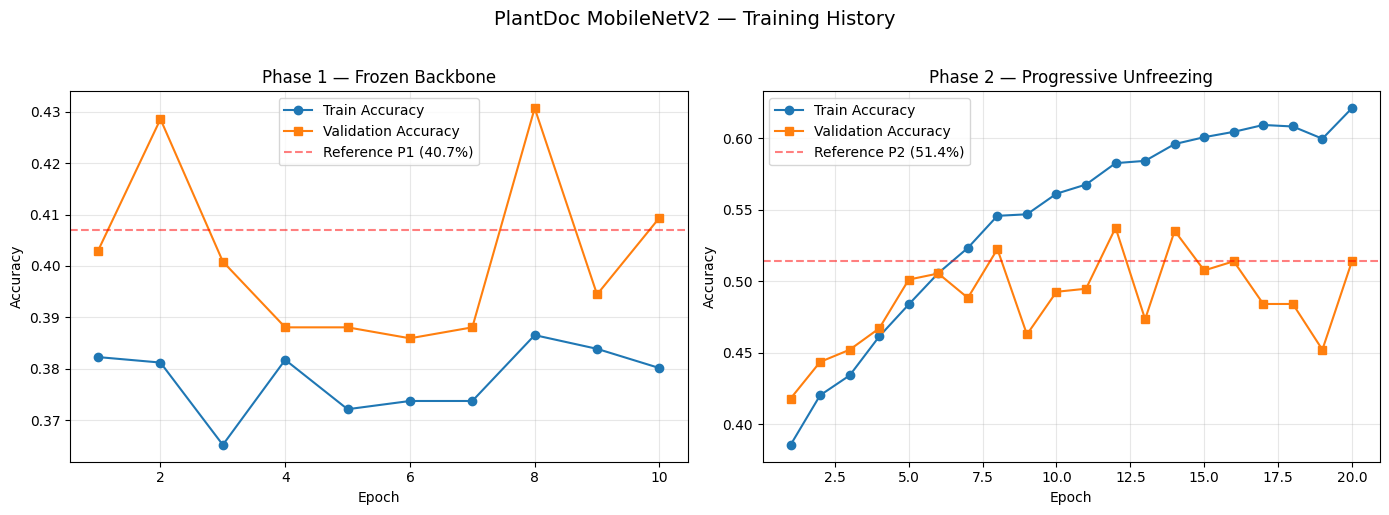

Plot saved to training_history.png


In [30]:
# ── TRAINING CURVES ──────────────────────────────────────────────────────────
# Visualizes training and validation accuracy across both training phases

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# ── PHASE 1 PLOT ─────────────────────────────────────────────────────────────
# Frozen backbone training history

p1_epochs = [h['epoch'] for h in history_p1]

axes[0].plot(
    p1_epochs,
    [h['tr_acc'] for h in history_p1],
    label='Train Accuracy',
    marker='o'
)

axes[0].plot(
    p1_epochs,
    [h['val_acc'] for h in history_p1],
    label='Validation Accuracy',
    marker='s'
)

# Reference accuracy line
axes[0].axhline(
    y=0.407,
    color='red',
    linestyle='--',
    alpha=0.5,
    label='Reference P1 (40.7%)'
)

axes[0].set_title('Phase 1 — Frozen Backbone')

axes[0].set_xlabel('Epoch')

axes[0].set_ylabel('Accuracy')

axes[0].legend()

axes[0].grid(True, alpha=0.3)

# ── PHASE 2 PLOT ─────────────────────────────────────────────────────────────
# Progressive unfreezing training history

p2_epochs = [h['epoch'] for h in history_p2]

axes[1].plot(
    p2_epochs,
    [h['tr_acc'] for h in history_p2],
    label='Train Accuracy',
    marker='o'
)

axes[1].plot(
    p2_epochs,
    [h['val_acc'] for h in history_p2],
    label='Validation Accuracy',
    marker='s'
)

# Reference accuracy line
axes[1].axhline(
    y=0.514,
    color='red',
    linestyle='--',
    alpha=0.5,
    label='Reference P2 (51.4%)'
)

axes[1].set_title('Phase 2 — Progressive Unfreezing')

axes[1].set_xlabel('Epoch')

axes[1].set_ylabel('Accuracy')

axes[1].legend()

axes[1].grid(True, alpha=0.3)

# ── GLOBAL FIGURE SETTINGS ──────────────────────────────────────────────────
plt.suptitle(
    'PlantDoc MobileNetV2 — Training History',
    fontsize=14,
    y=1.02
)

plt.tight_layout()

# ── SAVE FIGURE ──────────────────────────────────────────────────────────────
plt.savefig(
    'training_history.png',
    dpi=150,
    bbox_inches='tight'
)

# ── LOG FIGURE TO WANDB ─────────────────────────────────────────────────────
# Uploads the training curve image to Weights & Biases

wandb.log({
    "training_history_plot": wandb.Image(fig)
})

# ── DISPLAY FIGURE ───────────────────────────────────────────────────────────
plt.show()

print("Plot saved to training_history.png")

In [32]:
# ── SAVE FINAL MODEL + METADATA ──────────────────────────────────────────────
checkpoint = {
    'model_state_dict': best_model_state,
    'label2id': label2id,
    'id2label': id2label,
    'num_classes': num_classes,
    'best_val_acc_p1': best_val_acc_p1,
    'best_val_acc_p2': best_val_acc_p2,
    'history_p1': history_p1,
    'history_p2': history_p2,
}
torch.save(checkpoint, "plantdoc_mobilenetv2.pth")
print("Full checkpoint saved to plantdoc_mobilenetv2.pth")

Full checkpoint saved to plantdoc_mobilenetv2.pth


In [33]:
from google.colab import files

files.download("plantdoc_mobilenetv2.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>